# Three RAG Evaluation Metrics

Code companion for the article.

> **Setup:** activate the pixi env with `pixi shell`, then add your `ANTHROPIC_API_KEY` to `.env`.

## Imports

In [1]:
import re
import base64
from io import BytesIO
from typing import List

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from anthropic import Anthropic
from dotenv import load_dotenv

from multimodal_rag.embedder import CLIPEmbedder
from multimodal_rag.database import MilvusDatabase
from multimodal_rag.rag import RAGProcessor
from multimodal_rag.pipeline import search_and_respond, display_images

load_dotenv(dotenv_path="../.env")

/Users/rubenwinastwan/Documents/personal_project/blog-resources/articles/three-rag-evaluation-metrics/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

## Connect to the real multimodal RAG pipeline

Instead of hand-picking images and writing down an answer, every (answer, context) pair
below is a genuine output of the pipeline built in the *Building a Multimodal RAG Pipeline*
article: `CLIPEmbedder` for retrieval, `MilvusDatabase` for the vector search, and
`RAGProcessor` for generation, all imported straight from that project's `multimodal_rag`
package. We point the database at the `food_tiny.db` it already built.


> **Prerequisite:** run the `multimodal_rag.ipynb` notebook in
> `../../building-multimodal-rag/notebooks` at least once first — it ingests the
> `food101-tiny` dataset and builds `food_tiny.db` and `food_images/` that this notebook
> reads from.

In [2]:
import os

# Keep a handle on this notebook's own directory before we chdir below, so
# later cells can still reliably reference files like img/steak.jpg regardless
# of the process's current working directory.
NOTEBOOK_DIR = os.path.abspath(".")

# The database stores each image's filename as a path relative to
# building-multimodal-rag/notebooks (e.g. "./food_images/42.jpg"), so we chdir there
# before touching the database — the same way that notebook itself always ran.
os.chdir(os.path.abspath("../../building-multimodal-rag/notebooks"))

DB_PATH = "food_tiny.db"

embedder = CLIPEmbedder()
database = MilvusDatabase(db_path=DB_PATH)
rag_processor = RAGProcessor()

if not database.collection_has_data():
    raise RuntimeError(
        f"No data found in {os.path.abspath(DB_PATH)}. Run multimodal_rag.ipynb in "
        "building-multimodal-rag/notebooks first so it ingests the dataset and builds the collection."
    )

/Users/rubenwinastwan/Documents/personal_project/blog-resources/articles/three-rag-evaluation-metrics/.pixi/envs/default/lib/python3.12/site-packages/milvus_lite/__init__.py:15: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


# Side Dishes and Condiments for Steak

Steak is a versatile dish that pairs wonderfully with a variety of sides and condiments. As you can see in the images below, there are many delicious accompaniments commonly served alongside a steak:

## 🥄 Condiments & Sauces
- **Au jus** – A savory meat dripping sauce, visible in the small ramekin in the bottom image
- **Horseradish cream sauce** – A classic steakhouse condiment
- **Mustard-based sauces** – Such as Dijon or whole grain mustard sauce
- **Red wine reduction** – A rich, dark sauce seen in the top image
- **Béarnaise or butter sauce** – A creamy, herb-infused option

## 🥦 Vegetable Side Dishes
- **Sautéed or roasted mixed vegetables** – Including zucchini, bell peppers, carrots, and onions, as seen in the second and third images
- **Sautéed mushrooms** – A steakhouse classic, visible in the third image

## 🥔 Starchy Sides
- **Baked potato with sour cream** – One of the most iconic steak accompaniments, clearly visible in the bottom 

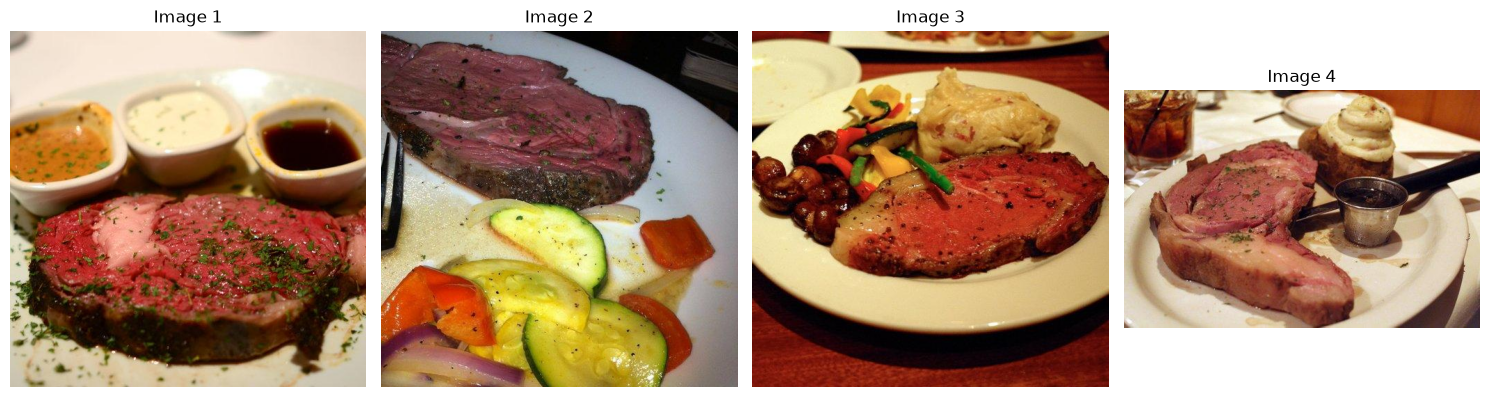

In [3]:
QUERY = "What kinds of side dishes and condiments do people eat with a steak?"

answer, context = search_and_respond(rag_processor, embedder, database, user_text_prompt=QUERY)

Both real runs above give us a real `(answer, context)` pair each. To also get a real
*off-topic answer paired with the on-topic images* (scenario 2 below), we make one more real
generation call: ask the ice-cream question but hand the model the steak images retrieved for
Query A as context. It's still a genuine API call and a genuine model output — we're just
choosing which real context goes with which real question.

## The RAGEvaluator

Each metric is a prompt sent to **Claude Sonnet 4.6** acting as an LLM-as-a-Judge.
The model receives the query, the answer, and the retrieved images (where relevant),
and returns a single score in `[0.0, 1.0]`.

In [4]:
class RAGEvaluator:
    # Despite being asked for a bare number, the judge tends to add a preamble or a
    # point-by-point walkthrough before it — especially once images are involved. This
    # suffix suppresses that explicitly; _score() also reads the *last* number in the
    # reply (not the first) as a defensive fallback.
    SCORE_ONLY_SUFFIX = (
        "Do not explain your reasoning or list observations. Respond with ONLY the "
        "numerical score, nothing else — no words, no labels, just the number (e.g., 0.8)."
    )

    def __init__(self, model: str = 'claude-opus-4-6'):
        self.client = Anthropic()
        self.model = model

    # ------------------------------------------------------------------ helpers

    def _images_to_content(self, images: List[Image.Image]) -> list:
        content = []
        for img in images:
            if img.mode != 'RGB':
                img = img.convert('RGB')
            buf = BytesIO()
            img.save(buf, format='JPEG')
            b64 = base64.b64encode(buf.getvalue()).decode('utf-8')
            content.append({
                'type': 'image',
                'source': {'type': 'base64', 'media_type': 'image/jpeg', 'data': b64},
            })
        return content

    def _score(self, messages: list) -> float:
        response = self.client.messages.create(
            model=self.model,
            max_tokens=60,
            temperature=0,
            messages=messages,
        )
        text = response.content[0].text.strip()
        matches = re.findall(r'\d+\.?\d*', text)
        if not matches:
            return 0.0
        return max(0.0, min(1.0, float(matches[-1])))

    # ------------------------------------------------------------ three metrics

    def evaluate_faithfulness(self, query: str, answer: str, images: List[Image.Image]) -> float:
        prompt = f'''Evaluate the faithfulness of the generated answer based on the provided images.

Query: {query}
Generated Answer: {answer}

Look at the provided images and determine:
1. Does the generated answer accurately describe what's shown in the images?
2. Is the answer consistent with the visual content?
3. Does the answer contain any information that contradicts what's visible?

Rate faithfulness on a scale of 0.0 to 1.0 where:
- 1.0: Answer is completely faithful to the visual evidence
- 0.5: Answer is partially faithful with some unsupported claims
- 0.0: Answer contradicts or is not supported by the evidence

{self.SCORE_ONLY_SUFFIX}'''
        content = [{'type': 'text', 'text': prompt}] + self._images_to_content(images)
        return self._score([{'role': 'user', 'content': content}])

    def evaluate_context_relevance(self, query: str, images: List[Image.Image]) -> float:
        prompt = f'''Evaluate how relevant these images are for answering the following query:

Query: {query}

Look at the provided images and rate their relevance on a scale of 0.0 to 1.0:
- 1.0: Images are highly relevant and contain information needed to answer the query
- 0.5: Images are somewhat relevant but may be missing key information
- 0.0: Images are not relevant to the query

{self.SCORE_ONLY_SUFFIX}'''
        content = [{'type': 'text', 'text': prompt}] + self._images_to_content(images)
        return self._score([{'role': 'user', 'content': content}])

    def evaluate_answer_relevance(self, query: str, answer: str) -> float:
        prompt = f'''Evaluate how well the given answer addresses the original query.

Original Query: {query}
Generated Answer: {answer}

Evaluate the answer based on:
1. Direct Relevance: Does the answer directly address what was asked?
2. Completeness: Does it provide sufficient information to satisfy the query?
3. Focus: Is it focused on the query without unnecessary tangents?
4. Appropriateness: Is it appropriate for the type of question asked?

Rate answer relevance on a scale of 0.0 to 1.0 where:
- 1.0: Perfectly addresses the query with complete, focused information
- 0.6: Partially addresses the query but misses some key aspects
- 0.2: Barely relates to the query
- 0.0: Completely irrelevant to the query

{self.SCORE_ONLY_SUFFIX}'''
        return self._score([{'role': 'user', 'content': prompt}])

    # --------------------------------------------------------------- combined

    def evaluate(self, query: str, answer: str, images: List[Image.Image]) -> dict:
        return {
            'faithfulness':       self.evaluate_faithfulness(query, answer, images),
            'context_relevance':  self.evaluate_context_relevance(query, images),
            'answer_relevance':   self.evaluate_answer_relevance(query, answer),
        }

## Test scenarios

We use **Query** (the steak question) as the fixed reference query throughout, and build
four `(answer, context)` combinations purely by mixing real, on-topic outputs and contexts with off-topic outputs and contexts

| Scenario | Answer | Retrieved context |
| --- | --- | --- |
| 1. Everything correct | `answer` (real, on-topic) | `context` (real, on-topic images) |
| 2. Off-topic answer | `answer_offtopic` (off-topic answer) | `context` (real, on-topic images) |
| 3. Wrong context | `answer` (real, on-topic) | `context_offtopic` (off-topic images) |
| 4. Both degraded | `answer_offtopic` (off-topic answer) | `context_offtopic` (off-topic images) |

In [5]:
answer_offtopic = "I am Batman"
context_offtopic = [Image.open(os.path.join(NOTEBOOK_DIR, "img/steak.jpg"))]

In [6]:
scenarios = [
    {'name': '1. Everything correct', 'answer': answer,        'images': context},
    {'name': '2. Off-topic answer',   'answer': answer_offtopic, 'images': context},
    {'name': '3. Wrong context',      'answer': answer,        'images': context_offtopic},
    {'name': '4. Both degraded',      'answer': answer_offtopic,        'images': context_offtopic},
]

## Running the evaluation

In [7]:
evaluator = RAGEvaluator()
results = []

for scenario in scenarios:
    print(f"Evaluating: {scenario['name']} ...")
    scores = evaluator.evaluate(QUERY, scenario['answer'], scenario['images'])
    results.append({
        'Scenario':         scenario['name'],
        'Faithfulness':     scores['faithfulness'],
        'Context Rel.':     scores['context_relevance'],
        'Answer Rel.':      scores['answer_relevance'],
    })
    print(
        f"  faithfulness={scores['faithfulness']:.1f}  "
        f"context_relevance={scores['context_relevance']:.1f}  "
        f"answer_relevance={scores['answer_relevance']:.1f}"
    )

Evaluating: 1. Everything correct ...
  faithfulness=0.7  context_relevance=0.9  answer_relevance=0.8
Evaluating: 2. Off-topic answer ...
  faithfulness=0.0  context_relevance=0.9  answer_relevance=0.0
Evaluating: 3. Wrong context ...
  faithfulness=0.2  context_relevance=0.1  answer_relevance=0.8
Evaluating: 4. Both degraded ...
  faithfulness=0.0  context_relevance=0.1  answer_relevance=0.0


I0712 15:57:13.949739 15665775 chttp2_transport.cc:1376] unix:/var/folders/1x/2_ykscdj75dff0v0wnkp0v5h0000gn/T/tmpc87y1la5_food_tiny.db.sock: Got goaway [11] err=UNAVAILABLE:GOAWAY received; Error code: 11; Debug Text: too_many_pings {http2_error:11}
E0712 15:57:13.952612 15665775 chttp2_transport.cc:1408] unix:/var/folders/1x/2_ykscdj75dff0v0wnkp0v5h0000gn/T/tmpc87y1la5_food_tiny.db.sock: Received a GOAWAY with error code ENHANCE_YOUR_CALM and debug data equal to "too_many_pings". Current keepalive time (before throttling): 10000ms


In [8]:
df = pd.DataFrame(results).set_index('Scenario')
df

,Faithfulness,Context Rel.,Answer Rel.
Scenario,,,
1. Everything correct,0.7,0.90,0.85
2. Off-topic answer,0.0,0.90,0.00
3. Wrong context,0.2,0.15,0.85
4. Both degraded,0.0,0.15,0.00


## Interpreting the results

Each metric isolates a different failure mode:

- **Scenario 1** — baseline: all three metrics should be near 1.0, since `answer` was really
  generated from `context`.
- **Scenario 2** — off-topic answer: faithfulness and answer relevance should collapse, while context relevance stays high because the retrieval was
  untouched.
- **Scenario 3** — wrong context: context relevance and faithfulness should drop, while answer relevance stays high
  since the answer itself still addresses the query perfectly.
- **Scenario 4** — both degraded: all three metrics should be low, since both the answer and
  the context are off-topic.

### What to fix

| Low metric | Root cause | Fix |
| --- | --- | --- |
| **Context relevance** | Retrieval | Better embeddings, reranking, or more candidates |
| **Faithfulness** | Grounding | Tighter prompt, context filtering before generation |
| **Answer relevance** | Generation | Different LLM/VLM, prompt tuning, temperature |
